# Pennsylvania sportsbook revenue walkthrough

## 1. Research question, scope, alternatives, and limitations

**Research question (hypothesis, not an approved mapping).**  
Does Pennsylvania publish a **gross** sportsbook revenue measure that can be retained **separately** from the **taxable** measure currently collected by `variant_gaming.states.pennsylvania`?

A column literally named “Revenue” does **not** by itself establish cross-state GGR comparability.

**Current collector behavior.** For Online Sports Wagering only, the production parser retains:

1. `Handle*` → `handle`
2. `Gross Revenue (Taxable)` → `taxable_revenue`
3. `State Tax Due (34%)` + `Local Share Assessment (2%)` → `tax`
4. `gross_revenue` / `adjusted_revenue` / `net_proceeds` → `NA`
5. `reported_revenue_name` = `"Gross Revenue (Taxable)"`

Native online rows also publish **`Revenue`** and **`Promotional Credits`**, which the collector currently ignores. Retail is intentionally not stored as sportsbook channel rows.

**Scope.**

- Inspect tracked fixtures and the existing parser first.
- Research official PGCB reports and definitions.
- Inventory reporting history from the official revenue landing page.
- Download a **bounded sample of six** FY “Monthly Sports Wagering Report Summary” Excel workbooks spanning ≥2 years, including the latest completed month.
- Store downloads under gitignored `data/raw/PA/`; never overwrite different bytes.
- Compare research extracts to the **existing parser on the same documents**.
- Production SQLite is **intentionally unavailable** here — do not create a substitute DB or claim a production-database comparison.

**Alternatives considered.**

| Alt | Description | Why deferred |
| --- | --- | --- |
| A | Keep taxable-only (status quo) | Drops a published native line |
| B | Map `Revenue` → `gross_revenue` while keeping taxable separate | Provisional only — `consolidate.revenue_basis` would auto-label the row `GGR` and notebook 40's handle+GGR cohort would include it; not a safe standalone change |
| C | Derive “gross” by reversing the 34% tax | Forbidden — do not infer by tax inversion |
| D | Treat `Revenue` as interchangeable with other states’ GGR | Unsupported by label alone |

**Limitations.**

- Six FY workbooks ≠ full-history validation.
- Fixture files are **test inputs** until official provenance is established.
- Publication/revision timestamps on the Excel objects are generally **unknown**.
- Footnotes explain Handle timing vs “Gross Revenue” but do **not** formally define the bare `Revenue` line vs `Gross Revenue (Taxable)`.
- Preserving a published field and approving cross-state comparability are **separate decisions**.
- The sample is **six fiscal-year workbooks** (monthly columns inside each FY file), not six independent monthly PDFs.

**Baseline.** This branch history includes `4074f969b2fd46f30a5584a18ab09acd5b0c0119`. Do not reset or change `main`.


## 2. Official sources and definitions

**What.** Record the official landing page, statute/regulation definitions, and workbook footnotes with direct links.

**Why.** Mapping decisions must cite regulator language, not industry secondary summaries.

**Assumptions.** PGCB Excel/PDF FY summaries are the authoritative public monthly series for sports wagering.

**Inspect.** Quoted definitions, footnote text, and how report line labels relate (or fail to relate) to statutory “gross sports wagering revenue.”


In [1]:
from __future__ import annotations

import hashlib
import json
import re
import subprocess
import sys
import warnings
from dataclasses import dataclass
from datetime import datetime, timezone
from decimal import Decimal, ROUND_HALF_UP
from io import BytesIO
from pathlib import Path
from urllib.parse import unquote, urljoin

import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from variant_gaming.common import (
    http_get,
    month_period,
    parse_money,
    project_root,
    save_raw_bytes,
    sha256_bytes,
    utc_now,
)
from variant_gaming.states.pennsylvania import (
    FY_TERM_IDS,
    LANDING_URL,
    SPORTS_REPORTED_REVENUE,
    _cell_text,
    _is_operator_header,
    _normalize_label,
    classify_pa_excel_link,
    discover_all_fy_links,
    find_header_row,
    parse_month_columns,
    parse_sports_workbook,
    build_sports_normalized,
)

ROOT = project_root()
RAW_PA = ROOT / "data" / "raw" / "PA"
FIXTURE_SPORTS = ROOT / "tests" / "fixtures" / "PA" / "sample_sports_wagering.xlsx"
BASELINE_SHA = "4074f969b2fd46f30a5584a18ab09acd5b0c0119"
SAMPLE_MANIFEST_PATH = RAW_PA / "_sample_manifest.json"

# A priori reconciliation tolerances from source cent precision (set BEFORE checks).
TOL_IDENTITY_USD = Decimal("0.01")  # published money appears in cents
TOL_TAX_RATE_MONTHLY_USD = Decimal("0.01")  # if tax were exactly round(month_taxable * rate, 2)


def git_head() -> str:
    try:
        return subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=ROOT, text=True).strip()
    except (OSError, subprocess.CalledProcessError):
        return "unavailable"


def baseline_is_ancestor(sha: str) -> bool:
    try:
        subprocess.check_call(
            ["git", "merge-base", "--is-ancestor", sha, "HEAD"],
            cwd=ROOT,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        return True
    except subprocess.CalledProcessError:
        return False


def to_decimal(value) -> Decimal | None:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return None
    if isinstance(value, Decimal):
        return value
    # Prefer str() to avoid binary float artifacts when value came from Excel as float.
    return Decimal(str(value))


def quantize_cent(value: Decimal | None) -> Decimal | None:
    if value is None:
        return None
    return value.quantize(Decimal("0.01"), rounding=ROUND_HALF_UP)


print("Repository root:", ROOT)
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("Git HEAD:", git_head())
print("Baseline present as ancestor:", baseline_is_ancestor(BASELINE_SHA))
assert baseline_is_ancestor(BASELINE_SHA), "Required baseline missing from branch history"
print("Official landing URL:", LANDING_URL)
print("Fixture path exists:", FIXTURE_SPORTS.exists())
print("Production DB path exists:", (ROOT / "data" / "gaming.sqlite").exists())
print("NOTE: Production SQLite intentionally unavailable — no DB comparison will be claimed.")

OFFICIAL_SOURCES = pd.DataFrame(
    [
        {
            "source": "PGCB Revenue Reports landing",
            "url": LANDING_URL,
            "role": "FY-filtered Excel/PDF sports wagering summaries",
        },
        {
            "source": "4 Pa.C.S. § 13C01 (Gross sports wagering revenue)",
            "url": "https://www.palegis.us/statutes/consolidated/view-statute?ttl=4&div=0&chapter=13C",
            "role": "Statutory definition of taxable gross sports wagering revenue",
        },
        {
            "source": "58 Pa. Code § 1401a.2 Definitions",
            "url": "https://www.law.cornell.edu/regulations/pennsylvania/58-Pa-Code-SS-1401a-2",
            "role": "Regulatory restatement of gross sports wagering revenue",
        },
        {
            "source": "4 Pa.C.S. § 13C62 Sports wagering tax",
            "url": "https://www.palegis.us/statutes/consolidated/view-statute?ttl=4&div=0&chapter=13C",
            "role": "34% tax on daily gross sports wagering revenue + local share framework",
        },
    ]
)
display(OFFICIAL_SOURCES)

STATUTE_PARAPHRASE = (
    "Gross sports wagering revenue is cash/cash-equivalents received from sports wagering "
    "minus cash/cash-equivalents paid to players as winning results, annuity funding for prizes, "
    "and actual cost of personal property distributed as a result of sports wagering "
    "(excluding travel, food, refreshments, lodging, or services). Counterfeits, non-convertible "
    "foreign currency, and unreimbursed fraud are excluded."
)
FOOTNOTE_QUOTE = (
    "*Sports Wagering Gross Revenue reflects the Handle (wagers) less ONLY the payouts on "
    "winning wagers made DURING the reporting month. This means the Handle includes wagers "
    "received for future events in which the payout would not be made on a winning ticket until "
    "a future month. Therefore, a relevant win percentage cannot be calculated by simply dividing "
    "the Gross Revenue by the Handle reported during a like period."
)
print("\nStatutory/regulatory paraphrase (gross sports wagering revenue):")
print(STATUTE_PARAPHRASE)
print("\nWorkbook footnote (Handle*):")
print(FOOTNOTE_QUOTE)
print(
    "\nDefinition gap: statute defines 'gross sports wagering revenue' used for the 34% tax; "
    "workbooks publish both 'Revenue' and 'Gross Revenue (Taxable)' plus 'Promotional Credits'. "
    "The footnote discusses timing of Gross Revenue vs Handle but does not define the bare "
    "'Revenue' line as a distinct legal term."
)


Repository root: /workspace
Python: 3.11.16
pandas: 3.0.5
Git HEAD: 67b0d29c6aebe1ef67f14fd24dbef54066e7f2d3
Baseline present as ancestor: True
Official landing URL: https://gamingcontrolboard.pa.gov/news-and-transparency/revenue
Fixture path exists: True
Production DB path exists: False
NOTE: Production SQLite intentionally unavailable — no DB comparison will be claimed.


,source,url,role
0,PGCB Revenue Reports landing,https://gamingcontrolboard.pa.gov/news-and-tra...,FY-filtered Excel/PDF sports wagering summaries
1,4 Pa.C.S. § 13C01 (Gross sports wagering revenue),https://www.palegis.us/statutes/consolidated/v...,Statutory definition of taxable gross sports w...
2,58 Pa. Code § 1401a.2 Definitions,https://www.law.cornell.edu/regulations/pennsy...,Regulatory restatement of gross sports wagerin...
3,4 Pa.C.S. § 13C62 Sports wagering tax,https://www.palegis.us/statutes/consolidated/v...,34% tax on daily gross sports wagering revenue...



Statutory/regulatory paraphrase (gross sports wagering revenue):
Gross sports wagering revenue is cash/cash-equivalents received from sports wagering minus cash/cash-equivalents paid to players as winning results, annuity funding for prizes, and actual cost of personal property distributed as a result of sports wagering (excluding travel, food, refreshments, lodging, or services). Counterfeits, non-convertible foreign currency, and unreimbursed fraud are excluded.

Workbook footnote (Handle*):
*Sports Wagering Gross Revenue reflects the Handle (wagers) less ONLY the payouts on winning wagers made DURING the reporting month. This means the Handle includes wagers received for future events in which the payout would not be made on a winning ticket until a future month. Therefore, a relevant win percentage cannot be calculated by simply dividing the Gross Revenue by the Handle reported during a like period.

Definition gap: statute defines 'gross sports wagering revenue' used for the 34% 

## 3. Optional bounded download (reuse retained files)

**What.** Discover FY sports-wagering Excel links from the official landing page / FY filters, then ensure a fixed sample of six workbooks exists under `data/raw/PA/`.

**Why.** Another analyst should be able to reproduce the sample. Reuse identical bytes; never overwrite a retained object with different content.

**Assumptions.** PGCB publishes one cumulative FY workbook per year with monthly columns (not twelve separate monthly files). Six FY workbooks therefore supply many monthly observations while staying within the bounded-sample rule.

**Inspect.** Manifest of URLs, retrieval timestamps (UTC), relative paths, SHA-256 hashes, sheet names, and whether `Revenue` / `Promotional Credits` / `Gross Revenue (Taxable)` appear.


In [2]:
SAMPLE_FY_LABELS = [
    "current",          # FY 2026/2027 — latest completed month
    "FY 2025/2026",
    "FY 2024/2025",
    "FY 2023/2024",
    "FY 2022/2023",     # older filename convention
    "FY 2020/2021",     # ≥2 years earlier; layout stress
]

OPTIONAL_DOWNLOAD = True  # set False to skip network and require an existing manifest/files


def inventory_history(session: requests.Session | None = None) -> pd.DataFrame:
    sess = session or requests.Session()
    links = discover_all_fy_links(session=sess)
    sports = [x for x in links if x["kind"] == "sports"]
    rows = []
    for item in sports:
        rows.append(
            {
                "fy_label": item["fy_label"],
                "fy_term_id": item["fy_term_id"],
                "filename": unquote(item["filename"]),
                "url": item["url"],
            }
        )
    return pd.DataFrame(rows)


def load_or_build_manifest(*, do_download: bool) -> pd.DataFrame:
    RAW_PA.mkdir(parents=True, exist_ok=True)
    if not do_download and SAMPLE_MANIFEST_PATH.exists():
        return pd.DataFrame(json.loads(SAMPLE_MANIFEST_PATH.read_text()))

    prior_by_sha = {}
    if SAMPLE_MANIFEST_PATH.exists():
        for prev in json.loads(SAMPLE_MANIFEST_PATH.read_text()):
            prior_by_sha[prev.get("sha256")] = prev

    sess = requests.Session()
    history = inventory_history(sess)
    print("Discovered sports-wagering FY workbooks:")
    display(history)

    by_fy = {r["fy_label"]: r for r in history.to_dict(orient="records")}
    missing = [k for k in SAMPLE_FY_LABELS if k not in by_fy]
    if missing:
        raise RuntimeError(f"Sample FY labels not discoverable: {missing}")

    retrieved_at = utc_now()
    manifest_rows = []
    for fy_label in SAMPLE_FY_LABELS:
        item = by_fy[fy_label]
        fname = unquote(item["filename"])
        safe_hint = re.sub(r"[^\w.\-]+", "_", fname).strip("_")
        reused = None
        for path in sorted(RAW_PA.rglob("*.xlsx")):
            if path.name.endswith(safe_hint) or safe_hint in path.name:
                if path.name.split("_", 1)[-1] == safe_hint or path.name.endswith(safe_hint):
                    reused = path
                    break

        if reused is not None:
            content = reused.read_bytes()
            digest = sha256_bytes(content)
            prev_row = prior_by_sha.get(digest) or {}
            source_url = prev_row.get("source_url") or item["url"]
            rel = str(reused.relative_to(ROOT)).replace("\\", "/")
            retrieved_stamp = prev_row.get("retrieved_at_utc")
            if not retrieved_stamp or str(retrieved_stamp).startswith("reused_from_folder"):
                retrieved_stamp = datetime.fromtimestamp(reused.stat().st_mtime, tz=timezone.utc).isoformat()
            print(f"REUSE {fy_label}: {rel}")
        else:
            if not do_download:
                raise RuntimeError(f"Missing retained file for {fy_label} and download disabled")
            resp = http_get(item["url"], session=sess)
            content = resp.content
            if not content.startswith(b"PK"):
                raise RuntimeError(f"Not XLSX for {fy_label}: {item['url']}")
            digest = sha256_bytes(content)
            path = save_raw_bytes(ROOT, "PA", content, fname, retrieved_at=retrieved_at)
            rel = str(path.relative_to(ROOT)).replace("\\", "/")
            source_url = resp.url or item["url"]
            retrieved_stamp = retrieved_at.isoformat()
            print(f"DOWNLOAD {fy_label}: {rel}")

        xl = pd.ExcelFile(BytesIO(content))
        sheet = next((n for n in xl.sheet_names if "footnote" not in n.casefold()), xl.sheet_names[0])
        frame = pd.read_excel(xl, sheet_name=sheet, header=None)
        labels = [_cell_text(v) for v in frame.iloc[:, 0].tolist() if _cell_text(v)]
        norms = {_normalize_label(x) for x in labels}
        footnote_sheet = next((n for n in xl.sheet_names if "footnote" in n.casefold()), None)
        footnote_text = None
        if footnote_sheet:
            fn = pd.read_excel(xl, sheet_name=footnote_sheet, header=None)
            footnote_text = " ".join(
                str(x) for x in fn.fillna("").astype(str).values.ravel() if str(x).strip()
            )

        months = []
        try:
            header_row = find_header_row(frame)
            months = [f"{y}-{m:02d}" for _, y, m in parse_month_columns(frame.iloc[header_row])]
        except ValueError:
            header_row = None

        manifest_rows.append(
            {
                "fy_label": fy_label,
                "source_url": source_url,
                "requested_url": item["url"],
                "filename": fname,
                "relative_path": rel,
                "sha256": digest,
                "bytes": len(content),
                "retrieved_at_utc": retrieved_stamp,
                "publication_timestamp_utc": None,
                "sheets": xl.sheet_names,
                "data_sheet": sheet,
                "shape": list(frame.shape),
                "month_headers": months,
                "has_revenue": "revenue" in norms,
                "has_promotional_credits": "promotional credits" in norms,
                "has_gross_revenue_taxable": "gross revenue (taxable)" in norms,
                "footnote_excerpt": (footnote_text or "")[:240],
            }
        )

    SAMPLE_MANIFEST_PATH.write_text(json.dumps(manifest_rows, indent=2))
    return pd.DataFrame(manifest_rows)


manifest = load_or_build_manifest(do_download=OPTIONAL_DOWNLOAD)
print("\nSample manifest (bounded n=6):")
display(
    manifest[
        [
            "fy_label",
            "source_url",
            "relative_path",
            "sha256",
            "retrieved_at_utc",
            "publication_timestamp_utc",
            "data_sheet",
            "shape",
            "has_revenue",
            "has_promotional_credits",
            "has_gross_revenue_taxable",
        ]
    ]
)
assert len(manifest) == 6
assert manifest["has_revenue"].all() and manifest["has_gross_revenue_taxable"].all()
print(
    "Latest sample FY label:",
    manifest.iloc[0]["fy_label"],
    "months:",
    manifest.iloc[0]["month_headers"][:3],
    "...",
)



Discovered sports-wagering FY workbooks:


,fy_label,fy_term_id,filename,url
0,current,NaN,FY26-27 Monthly Sports Wagering Report Summary...,https://gamingcontrolboard.pa.gov/sites/defaul...
1,FY 2025/2026,285.0,FY25-26 Monthly Sports Wagering Report Summary...,https://gamingcontrolboard.pa.gov/sites/defaul...
2,FY 2024/2025,252.0,FY24-25 Monthly Sports Wagering Report Summary...,https://gamingcontrolboard.pa.gov/sites/defaul...
3,FY 2023/2024,115.0,FY23-24 Monthly Sports Wagering Report Summary...,https://gamingcontrolboard.pa.gov/sites/defaul...
4,FY 2022/2023,50.0,Gaming_Revenue_Monthly_Sports_Wagering_FY20222...,https://gamingcontrolboard.pa.gov/sites/defaul...
5,FY 2021/2022,49.0,Gaming_Revenue_Monthly_Sports_Wagering_FY20212...,https://gamingcontrolboard.pa.gov/sites/defaul...
6,FY 2020/2021,110.0,Gaming_Revenue_Monthly_Sports_Wagering_FY20202...,https://gamingcontrolboard.pa.gov/sites/defaul...
7,FY 2019/2020,114.0,Gaming_Revenue_Monthly_Sports_Wagering_FY20192...,https://gamingcontrolboard.pa.gov/sites/defaul...


REUSE current: data/raw/PA/2026-09-05/56121e3d1f99813dc6ba40829f5a3945e9e214eba8ea85382d4d5b94f0a55040_FY26-27_Monthly_Sports_Wagering_Report_Summary.xlsx
REUSE FY 2025/2026: data/raw/PA/2026-09-05/eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c685224f14af06418951_FY25-26_Monthly_Sports_Wagering_Report_Summary.xlsx


REUSE FY 2024/2025: data/raw/PA/2026-09-05/6a9b3540e596a0ad34bfbdc72566569ba6a3730f4bf27cedd2795bd8f19b88f4_FY24-25_Monthly_Sports_Wagering_Report_Summary_.xlsx
REUSE FY 2023/2024: data/raw/PA/2026-09-05/e18d4146b0b4e5ead7806364a06816c6327b5c03b65ac602e451da9d94d55f9e_FY23-24_Monthly_Sports_Wagering_Report_Summary.xlsx
REUSE FY 2022/2023: data/raw/PA/2026-09-05/a9141ebeac60ac0b0a589cacb0de12ebad0e5c6199f6c4a2cfbdf4644ca69a0b_Gaming_Revenue_Monthly_Sports_Wagering_FY20222023_1_.xlsx


REUSE FY 2020/2021: data/raw/PA/2026-09-05/3d8194863d368ff3b5c194331907b1840281cfdc86e83e6c316dbfb90e69767f_Gaming_Revenue_Monthly_Sports_Wagering_FY20202021.xlsx

Sample manifest (bounded n=6):


,fy_label,source_url,relative_path,sha256,retrieved_at_utc,publication_timestamp_utc,data_sheet,shape,has_revenue,has_promotional_credits,has_gross_revenue_taxable
0,current,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/56121e3d1f99813dc6ba408...,56121e3d1f99813dc6ba40829f5a3945e9e214eba8ea85...,2026-09-05T00:04:00.113617+00:00,None,FY 2026-27,"[401, 27]",True,True,True
1,FY 2025/2026,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/eb41d3c9d6f1e41e3f1d3bf...,eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c6...,2026-09-05T00:04:00.261624+00:00,None,FY 2025-26,"[401, 27]",True,True,True
2,FY 2024/2025,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/6a9b3540e596a0ad34bfbdc...,6a9b3540e596a0ad34bfbdc72566569ba6a3730f4bf27c...,2026-09-05T00:04:00.369629+00:00,None,FY 2024-25,"[422, 27]",True,True,True
3,FY 2023/2024,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/e18d4146b0b4e5ead780636...,e18d4146b0b4e5ead7806364a06816c6327b5c03b65ac6...,2026-09-05T00:04:00.461633+00:00,None,FY 2023-24,"[444, 27]",True,True,True
4,FY 2022/2023,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/a9141ebeac60ac0b0a589ca...,a9141ebeac60ac0b0a589cacb0de12ebad0e5c6199f6c4...,2026-09-05T00:04:00.553637+00:00,None,FY 2021-22,"[444, 27]",True,True,True
5,FY 2020/2021,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/3d8194863d368ff3b5c1943...,3d8194863d368ff3b5c194331907b1840281cfdc86e83e...,2026-09-05T00:04:00.657642+00:00,None,FY 2020-21,"[378, 27]",True,True,True


Latest sample FY label: current months: ['2026-07', '2026-08', '2026-09'] ...


## 4. Raw sheets/tables: shapes, columns, types, representative rows

**What.** Read each sample workbook (and the tracked fixture) without collapsing channels.

**Why.** Layout and metric vocabulary must be observed before any mapping claim.

**Assumptions.** First non-footnote sheet holds the monthly matrix; column 0 holds section/metric labels; month headers sit near the top.

**Inspect.** Shapes, dtypes of numeric cells, operator headers, and a representative online block.


In [3]:
def load_frame(path: Path) -> tuple[str, pd.DataFrame, str | None]:
    xl = pd.ExcelFile(path)
    sheet = next((n for n in xl.sheet_names if "footnote" not in n.casefold()), xl.sheet_names[0])
    frame = pd.read_excel(xl, sheet_name=sheet, header=None)
    footnote = next((n for n in xl.sheet_names if "footnote" in n.casefold()), None)
    return sheet, frame, footnote


def summarize_raw(path: Path, label: str) -> dict:
    sheet, frame, footnote = load_frame(path)
    header_row = find_header_row(frame)
    months = parse_month_columns(frame.iloc[header_row])
    labels = [_cell_text(v) for v in frame.iloc[:, 0].tolist() if _cell_text(v)]
    # Representative numeric non-null count for first month column
    first_month_col = months[0][0]
    month_series = pd.to_numeric(frame.iloc[header_row + 1 :, first_month_col], errors="coerce")
    return {
        "label": label,
        "path": str(path.relative_to(ROOT)).replace("\\", "/"),
        "sheet": sheet,
        "footnote_sheet": footnote,
        "shape": frame.shape,
        "header_row": header_row,
        "n_month_cols": len(months),
        "first_month": f"{months[0][1]}-{months[0][2]:02d}" if months else None,
        "last_month": f"{months[-1][1]}-{months[-1][2]:02d}" if months else None,
        "n_labels": len(labels),
        "first_month_numeric_non_null": int(month_series.notna().sum()),
        "first_month_numeric_dtype_sample": str(month_series.dropna().head(3).tolist()),
    }


raw_summaries = [summarize_raw(FIXTURE_SPORTS, "TRACKED_FIXTURE")]
for row in manifest.to_dict(orient="records"):
    raw_summaries.append(summarize_raw(ROOT / row["relative_path"], row["fy_label"]))
raw_summary_df = pd.DataFrame(raw_summaries)
display(raw_summary_df)

# Show fixture online block (test input — provenance not independently established here)
sheet, fixture_frame, _ = load_frame(FIXTURE_SPORTS)
print("\nTracked fixture — full grid (test input):")
display(fixture_frame.dropna(how="all").head(45))

# Representative official online block from latest sample (STATEWIDE / GRAND TOTAL)
latest_path = ROOT / manifest.iloc[0]["relative_path"]
_, latest_frame, _ = load_frame(latest_path)
header_row = find_header_row(latest_frame)
# Find GRAND TOTAL online section start
grand_idx = None
for i, v in enumerate(latest_frame.iloc[:, 0].tolist()):
    if _normalize_label(_cell_text(v)) == "grand total":
        grand_idx = i
        break
assert grand_idx is not None
print("\nLatest official sample — GRAND TOTAL block (first month columns):")
cols = [0] + [c for c, _, _ in parse_month_columns(latest_frame.iloc[header_row])[:2]]
display(latest_frame.iloc[grand_idx : grand_idx + 25, cols])


,label,path,sheet,footnote_sheet,shape,header_row,n_month_cols,first_month,last_month,n_labels,first_month_numeric_non_null,first_month_numeric_dtype_sample
0,TRACKED_FIXTURE,tests/fixtures/PA/sample_sports_wagering.xlsx,FY 2025-26,Footnotes,"(44, 5)",3,2,2025-07,2025-08,22,14,"[1000.0, 100.0, 100.0]"
1,current,data/raw/PA/2026-09-05/56121e3d1f99813dc6ba408...,FY 2026-27,Footnotes,"(401, 27)",3,12,2026-07,2027-06,361,288,"[16912561.37, 1750265.22, 213995.89]"
2,FY 2025/2026,data/raw/PA/2026-09-05/eb41d3c9d6f1e41e3f1d3bf...,FY 2025-26,Footnotes,"(401, 27)",3,12,2025-07,2026-06,361,288,"[18711614.18, 2000879.5, 315684.91]"
3,FY 2024/2025,data/raw/PA/2026-09-05/6a9b3540e596a0ad34bfbdc...,FY 2024-25,Footnotes,"(422, 27)",3,12,2024-07,2025-06,381,304,"[19486072.26, 2262880.04, 459473.65]"
4,FY 2023/2024,data/raw/PA/2026-09-05/e18d4146b0b4e5ead780636...,FY 2023-24,Footnotes,"(444, 27)",3,12,2023-07,2024-06,401,320,"[14453269.98, 1363031.65, 1041.48]"
5,FY 2022/2023,data/raw/PA/2026-09-05/a9141ebeac60ac0b0a589ca...,FY 2021-22,Footnotes,"(444, 27)",3,12,2022-07,2023-06,401,304,"[21256090.99, 2087147.8699999999, 490864.75]"
6,FY 2020/2021,data/raw/PA/2026-09-05/3d8194863d368ff3b5c1943...,FY 2020-21,Footnotes,"(378, 27)",3,12,2020-07,2021-06,341,272,"[822461.13, 98298.35, 0.0]"



Tracked fixture — full grid (test input):


,0,1,2,3,4
2,MONTHLY SPORTS WAGERING REPORT,NaN,NaN,NaN,NaN
3,NaN,NaN,July 2025,NaN,August 2025
5,HOLLYWOOD CASINO,NaN,NaN,NaN,NaN
6,Total Sports Wagering,NaN,NaN,NaN,NaN
7,Handle*,NaN,1000,NaN,1100
9,Gross Revenue (Taxable),NaN,100,NaN,110
12,Retail Sports Wagering,NaN,NaN,NaN,NaN
13,Handle*,NaN,100,NaN,50
14,Gross Revenue (Taxable),NaN,10,NaN,5
17,Online Sports Wagering,NaN,NaN,NaN,NaN



Latest official sample — GRAND TOTAL block (first month columns):


,0,2,4
381,GRAND TOTAL,NaN,NaN
382,Total Sports Wagering,NaN,NaN
383,Handle*,509536348.05,0
384,Revenue,64784104.48,0
385,Promotional Credits,12944516.59,0
386,Gross Revenue (Taxable),51839587.89,0
387,State Tax Due (34%),17625459.89,0
388,Local Share Assessment (2%),1036791.79,0
389,Retail Sports Wagering,NaN,NaN
390,Handle*,21148429.15,0


## 5. Missingness, duplicates, identifiers, units, coverage

**What.** Profile operators, channels, months with activity, duplicate keys, and units.

**Why.** Eligibility for dual retention depends on stable identifiers and honest missingness (especially retail lacking `Revenue`).

**Assumptions.** Money cells are USD. Empty future FY months are template placeholders (zeros), not observations.

**Inspect.** Coverage by FY, operator-label changes, and which metrics are absent by channel.


In [4]:
def extract_channel_long(frame: pd.DataFrame) -> pd.DataFrame:
    """Extract Total/Retail/Online metric observations without combining channels."""
    header_row = find_header_row(frame)
    months = parse_month_columns(frame.iloc[header_row])
    records: list[dict] = []
    current_operator: str | None = None
    current_channel: str | None = None
    for row_index in range(header_row + 1, len(frame)):
        label = _cell_text(frame.iloc[row_index, 0])
        if not label:
            continue
        norm = _normalize_label(label)
        if _is_operator_header(label):
            current_operator = label.strip()
            current_channel = None
            continue
        if norm == "total sports wagering":
            current_channel = "total"
            continue
        if norm == "retail sports wagering":
            current_channel = "retail"
            continue
        if norm == "online sports wagering":
            current_channel = "online"
            continue
        if current_operator is None or current_channel is None:
            continue
        metric = None
        if norm in {"handle*", "handle"}:
            metric = "handle"
        elif norm == "revenue":
            metric = "revenue"
        elif norm == "promotional credits":
            metric = "promotional_credits"
        elif norm == "gross revenue (taxable)":
            metric = "gross_revenue_taxable"
        elif norm.startswith("state tax due"):
            metric = "state_tax"
        elif norm.startswith("local share assessment"):
            metric = "local_share"
        else:
            continue
        for col_index, year, month in months:
            raw = frame.iloc[row_index, col_index]
            if raw is None or (isinstance(raw, float) and pd.isna(raw)):
                value = None
            else:
                value = to_decimal(raw)
            records.append(
                {
                    "operator_native": current_operator,
                    "channel": current_channel,
                    "metric": metric,
                    "year": year,
                    "month": month,
                    "period_start": month_period(year, month)[0],
                    "value": value,
                }
            )
    return pd.DataFrame.from_records(records)


def long_to_wide(long_df: pd.DataFrame) -> pd.DataFrame:
    if long_df.empty:
        return long_df
    piv = (
        long_df.pivot_table(
            index=["operator_native", "channel", "year", "month", "period_start"],
            columns="metric",
            values="value",
            aggfunc="first",
        )
        .reset_index()
    )
    piv.columns.name = None
    return piv


def drop_template_placeholders(wide: pd.DataFrame) -> pd.DataFrame:
    money_cols = [
        c
        for c in [
            "handle",
            "revenue",
            "promotional_credits",
            "gross_revenue_taxable",
            "state_tax",
            "local_share",
        ]
        if c in wide.columns
    ]
    if not money_cols:
        return wide.iloc[0:0]
    active = []
    for _, row in wide.iterrows():
        vals = [row[c] for c in money_cols]
        if all(v is None or (isinstance(v, float) and pd.isna(v)) for v in vals):
            continue
        if all((v is None) or (v == 0) for v in vals):
            continue
        active.append(row)
    return pd.DataFrame(active)


wide_parts = []
for row in manifest.to_dict(orient="records"):
    path = ROOT / row["relative_path"]
    _, frame, _ = load_frame(path)
    long_df = extract_channel_long(frame)
    wide = drop_template_placeholders(long_to_wide(long_df))
    wide["source_fy"] = row["fy_label"]
    wide["source_url"] = row["source_url"]
    wide["source_file"] = row["relative_path"]
    wide["source_sha256"] = row["sha256"]
    wide["retrieved_at_utc"] = row["retrieved_at_utc"]
    wide_parts.append(wide)

observations = pd.concat(wide_parts, ignore_index=True)
print("Active operator×channel×month rows across sample:", len(observations))

# Metric presence by channel
presence = []
for channel, grp in observations.groupby("channel"):
    presence.append(
        {
            "channel": channel,
            "n_rows": len(grp),
            "revenue_non_null": int(grp["revenue"].notna().sum()) if "revenue" in grp else 0,
            "promo_non_null": int(grp["promotional_credits"].notna().sum()) if "promotional_credits" in grp else 0,
            "taxable_non_null": int(grp["gross_revenue_taxable"].notna().sum()),
            "state_tax_non_null": int(grp["state_tax"].notna().sum()),
            "local_share_non_null": int(grp["local_share"].notna().sum()),
            "handle_non_null": int(grp["handle"].notna().sum()),
            "n_operators": grp["operator_native"].nunique(),
            "n_periods": grp["period_start"].nunique(),
            "period_min": grp["period_start"].min(),
            "period_max": grp["period_start"].max(),
        }
    )
presence_df = pd.DataFrame(presence).sort_values("channel")
display(presence_df)

# Duplicate keys within a source file
key_cols = ["source_sha256", "operator_native", "channel", "period_start"]
dupes = observations.groupby(key_cols).size().reset_index(name="n").query("n > 1")
print("Duplicate operator×channel×month keys within a source:", len(dupes))
display(dupes.head())

# Native operator labels across years (flag case / naming drift)
operators_by_fy = (
    observations.query("channel == 'online'")
    .groupby("source_fy")["operator_native"]
    .agg(lambda s: sorted(set(s)))
    .to_dict()
)
print("Online operator labels by FY sample (native spellings preserved):")
for fy, ops in operators_by_fy.items():
    print(f"  {fy}: {len(ops)} operators — e.g. {ops[:4]}")

# Units
print("\nUnits: USD as published (cent precision in source floats). Frequency: monthly columns inside FY workbooks.")
print("Identifiers: native certificate-holder labels + GRAND TOTAL control total; channel section headers.")

# --- Sample / observation grain (six FY workbooks) ---
# Each retained file is a fiscal-year workbook with monthly columns.
# Observations below are operator × channel × calendar-month cells from those workbooks.
# Control totals (GRAND TOTAL) and Total-channel rows are retained for diagnostics but are
# NOT independent validation of Online operator-month arithmetic.

print("\n=== Sample grain: six fiscal-year workbooks ===")
print("Workbook count:", len(manifest))
print("Workbooks:")
display(
    manifest[
        [
            "fy_label",
            "relative_path",
            "data_sheet",
            "month_headers",
            "source_url",
            "sha256",
            "retrieved_at_utc",
        ]
    ]
)

cov_rows = []
for (fy, ch), g in observations.groupby(["source_fy", "channel"]):
    periods = sorted(g["period_start"].unique())
    cov_rows.append(
        {
            "source_fy": fy,
            "channel": ch,
            "period_min": periods[0],
            "period_max": periods[-1],
            "n_distinct_months": len(periods),
            "months": periods,
        }
    )
coverage_df = pd.DataFrame(cov_rows)
print("\nActual monthly date coverage by workbook × channel (active cells only):")
display(coverage_df)

online_ops = observations.query("channel == 'online'").copy()
online_ops_only = online_ops[online_ops["operator_native"].map(_normalize_label) != "grand total"].copy()
online_control = online_ops[online_ops["operator_native"].map(_normalize_label) == "grand total"].copy()

print("Unique online operator-month rows (excluding GRAND TOTAL):", len(online_ops_only))
print("Unique online GRAND TOTAL month rows (control totals):", len(online_control))
print(
    "Unique online operator labels (excl. GRAND TOTAL):",
    online_ops_only["operator_native"].nunique(),
)
print(
    "Online calendar months covered (excl. GRAND TOTAL):",
    sorted(online_ops_only["period_start"].unique()),
)

overlap_key = ["operator_native", "channel", "period_start"]
overlap_counts = (
    observations.groupby(overlap_key)["source_fy"]
    .agg(n_workbooks="nunique", workbooks=lambda s: sorted(set(s)))
    .reset_index()
)
overlaps = overlap_counts.query("n_workbooks > 1")
print("\nOverlapping operator×channel×month keys across workbooks:", len(overlaps))
display(overlaps.head(20) if len(overlaps) else overlaps)
print(
    "Note: FY workbooks do not normally overlap calendar months across different FYs; "
    "any overlap would be double-counted if treated as independent validation. "
    "Reconciliation denominators below are workbook-scoped row counts, not de-duplicated history."
)

print("\nExcluded from monthly Online identity denominator:")
print("  - Retail channel rows (no Revenue/Promo lines in general)")
print("  - Total channel rows (combined online+retail control section)")
print("  - FY YTD/total columns if present as non-month headers (parser uses named months only)")
print("  - All-zero template placeholder months (already dropped)")
print("  - GRAND TOTAL rows remain in observations for diagnostics but are control totals, not operator detail")

preview = online_ops[
    online_ops["revenue"].notna() & online_ops["gross_revenue_taxable"].notna()
].copy()
mask_nonzero = ~(
    (preview["revenue"].fillna(0) == 0)
    & (preview["promotional_credits"].fillna(0) == 0)
    & (preview["gross_revenue_taxable"].fillna(0) == 0)
)
preview = preview.loc[mask_nonzero]
print(
    "\nPreview count of online rows with both Revenue and Taxable published (nonzero):",
    len(preview),
)
print(
    "  of which GRAND TOTAL control:",
    int((preview["operator_native"].map(_normalize_label) == "grand total").sum()),
)
print(
    "  of which operator detail:",
    int((preview["operator_native"].map(_normalize_label) != "grand total").sum()),
)
print(
    "The §8 Online reconciliation denominator is this workbook-scoped cell count "
    "(operator detail + GRAND TOTAL controls with both lines). It is NOT six independent "
    "monthly report files and must not be read as N de-duplicated validated history months."
)



Active operator×channel×month rows across sample: 3041


,channel,n_rows,revenue_non_null,promo_non_null,taxable_non_null,state_tax_non_null,local_share_non_null,handle_non_null,n_operators,n_periods,period_min,period_max
0,online,790,790,790,790,790,790,790,19,61,2020-07-01,2026-07-01
1,retail,1151,0,0,1151,1151,1151,1151,25,72,2020-07-01,2027-06-01
2,total,1100,1100,1100,1100,1100,1100,1100,25,61,2020-07-01,2026-07-01


Duplicate operator×channel×month keys within a source: 0


,source_sha256,operator_native,channel,period_start,n


Online operator labels by FY sample (native spellings preserved):
  FY 2020/2021: 14 operators — e.g. ['GRAND TOTAL', "HARRAH'S", 'HOLLYWOOD CASINO', 'Hollywood Casino Morgantown']
  FY 2022/2023: 15 operators — e.g. ['GRAND TOTAL', "HARRAH'S", 'HOLLYWOOD CASINO', 'HOLLYWOOD CASINO AT THE MEADOWS']
  FY 2023/2024: 14 operators — e.g. ['GRAND TOTAL', "HARRAH'S", 'HOLLYWOOD CASINO', 'HOLLYWOOD CASINO AT THE MEADOWS']
  FY 2024/2025: 13 operators — e.g. ['GRAND TOTAL', "HARRAH'S", 'HOLLYWOOD CASINO', 'HOLLYWOOD CASINO AT THE MEADOWS']
  FY 2025/2026: 13 operators — e.g. ['GRAND TOTAL', "HARRAH'S", 'HOLLYWOOD CASINO', 'HOLLYWOOD CASINO AT THE MEADOWS']
  current: 12 operators — e.g. ['GRAND TOTAL', "HARRAH'S", 'HOLLYWOOD CASINO', 'HOLLYWOOD CASINO AT THE MEADOWS']

Units: USD as published (cent precision in source floats). Frequency: monthly columns inside FY workbooks.
Identifiers: native certificate-holder labels + GRAND TOTAL control total; channel section headers.

=== Sample grain: si

...


Actual monthly date coverage by workbook × channel (active cells only):


,source_fy,channel,period_min,period_max,n_distinct_months,months
0,FY 2020/2021,online,2020-07-01,2021-06-01,12,"[2020-07-01, 2020-08-01, 2020-09-01, 2020-10-0..."
1,FY 2020/2021,retail,2020-07-01,2021-06-01,12,"[2020-07-01, 2020-08-01, 2020-09-01, 2020-10-0..."
2,FY 2020/2021,total,2020-07-01,2021-06-01,12,"[2020-07-01, 2020-08-01, 2020-09-01, 2020-10-0..."
3,FY 2022/2023,online,2022-07-01,2023-06-01,12,"[2022-07-01, 2022-08-01, 2022-09-01, 2022-10-0..."
4,FY 2022/2023,retail,2022-07-01,2023-06-01,12,"[2022-07-01, 2022-08-01, 2022-09-01, 2022-10-0..."
5,FY 2022/2023,total,2022-07-01,2023-06-01,12,"[2022-07-01, 2022-08-01, 2022-09-01, 2022-10-0..."
6,FY 2023/2024,online,2023-07-01,2024-06-01,12,"[2023-07-01, 2023-08-01, 2023-09-01, 2023-10-0..."
7,FY 2023/2024,retail,2023-07-01,2024-06-01,12,"[2023-07-01, 2023-08-01, 2023-09-01, 2023-10-0..."
8,FY 2023/2024,total,2023-07-01,2024-06-01,12,"[2023-07-01, 2023-08-01, 2023-09-01, 2023-10-0..."
9,FY 2024/2025,online,2024-07-01,2025-06-01,12,"[2024-07-01, 2024-08-01, 2024-09-01, 2024-10-0..."


Unique online operator-month rows (excluding GRAND TOTAL): 729
Unique online GRAND TOTAL month rows (control totals): 61
Unique online operator labels (excl. GRAND TOTAL): 18
Online calendar months covered (excl. GRAND TOTAL): ['2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01', '2020-11-01', '2020-12-01', '2021-01-01', '2021-02-01', '2021-03-01', '2021-04-01', '2021-05-01', '2021-06-01', '2022-07-01', '2022-08-01', '2022-09-01', '2022-10-01', '2022-11-01', '2022-12-01', '2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01', '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01', '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01', '2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01', '2026-01-01', '2

,operator_native,channel,period_start,n_workbooks,workbooks


Note: FY workbooks do not normally overlap calendar months across different FYs; any overlap would be double-counted if treated as independent validation. Reconciliation denominators below are workbook-scoped row counts, not de-duplicated history.

Excluded from monthly Online identity denominator:
  - Retail channel rows (no Revenue/Promo lines in general)
  - Total channel rows (combined online+retail control section)
  - FY YTD/total columns if present as non-month headers (parser uses named months only)
  - All-zero template placeholder months (already dropped)
  - GRAND TOTAL rows remain in observations for diagnostics but are control totals, not operator detail

Preview count of online rows with both Revenue and Taxable published (nonzero): 790
  of which GRAND TOTAL control: 61
  of which operator detail: 729
The §8 Online reconciliation denominator is this workbook-scoped cell count (operator detail + GRAND TOTAL controls with both lines). It is NOT six independent monthly repo

## 6. Explicit monthly online versus retail extraction

**What.** Keep online and retail as separate observation sets. Do not add them into a blended sportsbook series here.

**Why.** The production collector stores online only; retail remains available in the same workbook for diagnostics.

**Assumptions.** Section headers `Online Sports Wagering` / `Retail Sports Wagering` / `Total Sports Wagering` delimit channels. `Total` is a control total, not a third market to dual-count with operator detail.

**Inspect.** Side-by-side month counts and a statewide online vs retail table for the latest completed month.


In [5]:
online = observations.query("channel == 'online'").copy()
retail = observations.query("channel == 'retail'").copy()
total = observations.query("channel == 'total'").copy()

print("Online rows:", len(online), "Retail rows:", len(retail), "Total-section rows:", len(total))
print("Online periods:", sorted(online["period_start"].unique())[:3], "...", sorted(online["period_start"].unique())[-3:])
print("Retail periods:", sorted(retail["period_start"].unique())[:3], "...", sorted(retail["period_start"].unique())[-3:])

# Latest completed month from latest FY sample (max period with statewide online activity)
latest_fy = manifest.iloc[0]["fy_label"]
latest_online = online.query("source_fy == @latest_fy")
latest_period = latest_online["period_start"].max()
print("Latest FY sample:", latest_fy, "latest completed online period_start:", latest_period)

def statewide_slice(df: pd.DataFrame, period: str) -> pd.DataFrame:
    return df[(df["period_start"] == period) & (df["operator_native"].map(_normalize_label) == "grand total")]


def fmt_money(series: pd.Series) -> pd.Series:
    return series.map(lambda x: None if x is None or (isinstance(x, float) and pd.isna(x)) else float(x))


cmp_cols = [
    "operator_native",
    "channel",
    "period_start",
    "handle",
    "revenue",
    "promotional_credits",
    "gross_revenue_taxable",
    "state_tax",
    "local_share",
]
latest_compare = pd.concat(
    [
        statewide_slice(online, latest_period),
        statewide_slice(retail, latest_period),
        statewide_slice(total, latest_period),
    ],
    ignore_index=True,
)
for c in ["handle", "revenue", "promotional_credits", "gross_revenue_taxable", "state_tax", "local_share"]:
    if c in latest_compare:
        latest_compare[c] = fmt_money(latest_compare[c])
display(latest_compare[cmp_cols])

print(
    "Note: Retail statewide rows typically omit Revenue and Promotional Credits; "
    "Online and Total publish those lines. Do not invent retail Revenue."
)


Online rows: 790 Retail rows: 1151 Total-section rows: 1100
Online periods: ['2020-07-01', '2020-08-01', '2020-09-01'] ... ['2026-05-01', '2026-06-01', '2026-07-01']
Retail periods: ['2020-07-01', '2020-08-01', '2020-09-01'] ... ['2027-04-01', '2027-05-01', '2027-06-01']
Latest FY sample: current latest completed online period_start: 2026-07-01


,operator_native,channel,period_start,handle,revenue,promotional_credits,gross_revenue_taxable,state_tax,local_share
0,GRAND TOTAL,online,2026-07-01,4.883879e+08,62508267.77,12944516.59,49563751.18,16851675.40,991275.04
1,GRAND TOTAL,retail,2026-07-01,2.114843e+07,NaN,NaN,2275836.71,773784.49,45516.75
2,GRAND TOTAL,total,2026-07-01,5.095363e+08,64784104.48,12944516.59,51839587.89,17625459.89,1036791.79


Note: Retail statewide rows typically omit Revenue and Promotional Credits; Online and Total publish those lines. Do not invent retail Revenue.


## 7. Native revenue fields side by side

**What.** For online observations, show `Revenue`, `Promotional Credits`, `Gross Revenue (Taxable)`, state tax, and local share together.

**Why.** Dual retention is only meaningful if both revenue lines are actually present on the same rows.

**Assumptions.** Negatives are real (preserved). Missing promo on a row where Revenue exists is still possible and must remain missing unless published.

**Inspect.** Sample rows including negatives and promo-heavy operators.


In [6]:
side = online.copy()
for c in ["handle", "revenue", "promotional_credits", "gross_revenue_taxable", "state_tax", "local_share"]:
    side[c] = side[c].map(lambda x: None if x is None or (isinstance(x, float) and pd.isna(x)) else float(x))

side["operator_is_statewide"] = side["operator_native"].map(lambda s: _normalize_label(s) == "grand total")

print("Online side-by-side sample (includes negatives if present):")
display(
    side.sort_values(["period_start", "operator_native"])
    [
        [
            "source_fy",
            "operator_native",
            "period_start",
            "handle",
            "revenue",
            "promotional_credits",
            "gross_revenue_taxable",
            "state_tax",
            "local_share",
        ]
    ]
    .head(20)
)

negatives = side[side["gross_revenue_taxable"].fillna(0) < 0]
print("Online rows with negative taxable:", len(negatives))
display(negatives.head(10))

promo_share = side.dropna(subset=["revenue", "promotional_credits"]).copy()
promo_share["promo_over_revenue"] = promo_share["promotional_credits"] / promo_share["revenue"].replace(0, pd.NA)
print("Promo/Revenue distribution (online, where both present):")
display(promo_share["promo_over_revenue"].describe())


Online side-by-side sample (includes negatives if present):


,source_fy,operator_native,period_start,handle,revenue,promotional_credits,gross_revenue_taxable,state_tax,local_share
2509,FY 2020/2021,GRAND TOTAL,2020-07-01,1.553545e+08,12382517.08,5504385.75,6878131.33,2338564.64,137562.62
2545,FY 2020/2021,HARRAH'S,2020-07-01,2.495836e+05,30833.55,5995.00,24838.55,8445.11,496.77
2680,FY 2020/2021,MEADOWS,2020-07-01,3.914358e+07,2871177.84,1031241.99,1839935.85,625578.19,36798.72
2716,FY 2020/2021,MOHEGAN,2020-07-01,2.602114e+06,655067.95,502352.29,152715.66,51923.32,3054.31
2776,FY 2020/2021,MOUNT AIRY,2020-07-01,1.194401e+07,1348402.84,383351.13,965051.71,328117.58,19301.03
2812,FY 2020/2021,PARX CASINO,2020-07-01,9.089272e+06,866206.62,43505.24,822701.38,279718.47,16454.03
2848,FY 2020/2021,PRESQUE ISLE,2020-07-01,4.226377e+05,33051.36,1134.15,31917.21,10851.85,638.34
2884,FY 2020/2021,RIVERS - PHILADELPHIA,2020-07-01,1.274373e+07,1035058.05,138862.57,896195.48,304706.46,17923.91
2920,FY 2020/2021,RIVERS - PITTSBURGH,2020-07-01,1.038063e+07,904489.53,193044.34,711445.19,241891.36,14228.90
2978,FY 2020/2021,VALLEY FORGE CASINO,2020-07-01,6.877896e+07,4638229.34,3204899.04,1433330.30,487332.30,28666.61


Online rows with negative taxable: 87


,operator_native,channel,year,month,period_start,gross_revenue_taxable,handle,local_share,promotional_credits,revenue,state_tax,source_fy,source_url,source_file,source_sha256,retrieved_at_utc,operator_is_statewide
325,MOHEGAN,online,2025,11,2025-11-01,-21202.37,4.201443e+05,-424.05,0.00,-21202.37,-7208.81,FY 2025/2026,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/eb41d3c9d6f1e41e3f1d3bf...,eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c6...,2026-09-05T00:04:00.261624+00:00,False
326,MOHEGAN,online,2025,12,2025-12-01,-7125.03,1.317645e+06,-142.50,159759.75,152634.72,-2422.51,FY 2025/2026,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/eb41d3c9d6f1e41e3f1d3bf...,eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c6...,2026-09-05T00:04:00.261624+00:00,False
467,PRESQUE ISLE,online,2025,9,2025-09-01,-1374448.66,3.924577e+07,-27488.97,5843000.34,4468551.68,-467312.54,FY 2025/2026,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/eb41d3c9d6f1e41e3f1d3bf...,eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c6...,2026-09-05T00:04:00.261624+00:00,False
609,WIND CREEK,online,2025,7,2025-07-01,-2954.00,1.523058e+04,-59.08,0.00,-2954.00,-1004.36,FY 2025/2026,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/eb41d3c9d6f1e41e3f1d3bf...,eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c6...,2026-09-05T00:04:00.261624+00:00,False
610,WIND CREEK,online,2025,8,2025-08-01,-1281.23,0.000000e+00,-25.62,0.00,-1281.23,-435.62,FY 2025/2026,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/eb41d3c9d6f1e41e3f1d3bf...,eb41d3c9d6f1e41e3f1d3bfbbe371a566f3d2456d4e9c6...,2026-09-05T00:04:00.261624+00:00,False
672,HARRAH'S,online,2024,8,2024-08-01,-86321.46,1.790965e+07,-1726.43,283638.15,197316.69,-29349.30,FY 2024/2025,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/6a9b3540e596a0ad34bfbdc...,6a9b3540e596a0ad34bfbdc72566569ba6a3730f4bf27c...,2026-09-05T00:04:00.369629+00:00,False
678,HARRAH'S,online,2025,2,2025-02-01,-191998.10,2.036360e+07,-3839.96,306805.32,114807.22,-65279.35,FY 2024/2025,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/6a9b3540e596a0ad34bfbdc...,6a9b3540e596a0ad34bfbdc72566569ba6a3730f4bf27c...,2026-09-05T00:04:00.369629+00:00,False
712,HOLLYWOOD CASINO,online,2024,12,2024-12-01,-440375.52,4.146697e+07,-8807.51,1264775.46,824399.94,-149727.68,FY 2024/2025,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/6a9b3540e596a0ad34bfbdc...,6a9b3540e596a0ad34bfbdc72566569ba6a3730f4bf27c...,2026-09-05T00:04:00.369629+00:00,False
714,HOLLYWOOD CASINO,online,2025,2,2025-02-01,-239021.41,2.720089e+07,-4780.43,1015157.39,776135.98,-81267.28,FY 2024/2025,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/6a9b3540e596a0ad34bfbdc...,6a9b3540e596a0ad34bfbdc72566569ba6a3730f4bf27c...,2026-09-05T00:04:00.369629+00:00,False
750,HOLLYWOOD CASINO AT THE MEADOWS,online,2025,2,2025-02-01,-186026.27,1.788789e+08,-3720.53,8839103.28,8653077.01,-63248.93,FY 2024/2025,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/6a9b3540e596a0ad34bfbdc...,6a9b3540e596a0ad34bfbdc72566569ba6a3730f4bf27c...,2026-09-05T00:04:00.369629+00:00,False


Promo/Revenue distribution (online, where both present):


count    790.000000
mean       0.381693
std        0.933791
min      -10.825410
25%        0.171768
50%        0.281856
75%        0.459372
max       12.399335
Name: promo_over_revenue, dtype: float64

## 8. Candidate mapping and arithmetic reconciliation

**What.** Test the candidate identity `Revenue − Promotional Credits = Gross Revenue (Taxable)` on **Online** rows, and separately on **Total** rows as a diagnostic only. Also check whether monthly `State Tax Due (34%)` equals `round(taxable × 0.34, ¢)`.

**Why.** Dual storage requires evidence that the two revenue lines are distinct published measures with a documented relationship — not a silent rename.

**Assumptions / rules.**

- Tolerances were fixed a priori at **$0.01** (cent precision). Failures are shown, not used to widen tolerance.
- Do **not** infer gross by reversing tax.
- Label `Revenue − Taxable` neutrally as a published difference coinciding with `Promotional Credits` when the identity holds; do not rename it “free play” unless PGCB says so.
- Do not combine online+retail or monthly+YTD.
- **Do not generalize Online validation to Retail or Total.** Total-section failures are displayed in full; they do not invalidate Online arithmetic unless Online rows themselves fail.
- The Online reconciliation denominator is workbook-scoped active Online cells with both `Revenue` and `Taxable` published (including GRAND TOTAL control rows where those lines exist). It is **not** a de-duplicated multi-year panel and must not be read as N independent monthly report files.

**Inspect.** Pass/fail counts, max absolute discrepancy, explicit denominators, and **all** Total-section failures with provenance.


In [7]:
def reconcile_identity(df: pd.DataFrame, channel: str) -> pd.DataFrame:
    sub = df.query("channel == @channel").copy()
    rows = []
    for _, r in sub.iterrows():
        rev = quantize_cent(to_decimal(r.get("revenue")))
        promo = to_decimal(r.get("promotional_credits"))
        taxb = quantize_cent(to_decimal(r.get("gross_revenue_taxable")))
        if rev is None or taxb is None:
            continue
        if rev == 0 and (promo is None or promo == 0) and taxb == 0:
            continue
        promo_q = quantize_cent(promo if promo is not None else Decimal("0"))
        diff = rev - promo_q - taxb
        rows.append(
            {
                "source_fy": r["source_fy"],
                "source_url": r["source_url"],
                "source_file": r["source_file"],
                "operator_native": r["operator_native"],
                "channel": channel,
                "period_start": r["period_start"],
                "revenue": float(rev),
                "promotional_credits": float(promo_q) if promo_q is not None else None,
                "gross_revenue_taxable": float(taxb),
                "revenue_minus_promo_minus_taxable": float(diff),
                "abs_diff": float(abs(diff)),
                "pass_tol_0_01": abs(diff) <= TOL_IDENTITY_USD,
            }
        )
    return pd.DataFrame(rows)


online_identity = reconcile_identity(observations, "online")
total_identity = reconcile_identity(observations, "total")

# Attach sheet names from manifest for provenance
sheet_by_fy = dict(zip(manifest["fy_label"], manifest["data_sheet"]))
online_identity["data_sheet"] = online_identity["source_fy"].map(sheet_by_fy)
total_identity["data_sheet"] = total_identity["source_fy"].map(sheet_by_fy)

online_ops_id = online_identity[
    online_identity["operator_native"].map(_normalize_label) != "grand total"
]
online_ctrl_id = online_identity[
    online_identity["operator_native"].map(_normalize_label) == "grand total"
]

print(
    "ONLINE identity Revenue - Promo = Taxable\n"
    f"  all online rows with both lines: n={len(online_identity)} "
    f"pass@{TOL_IDENTITY_USD}={int(online_identity['pass_tol_0_01'].sum())} "
    f"fail={int((~online_identity['pass_tol_0_01']).sum())} "
    f"max_abs={online_identity['abs_diff'].max() if len(online_identity) else None}"
)
print(
    f"  operator-detail only: n={len(online_ops_id)} "
    f"pass={int(online_ops_id['pass_tol_0_01'].sum())} "
    f"fail={int((~online_ops_id['pass_tol_0_01']).sum())}"
)
print(
    f"  GRAND TOTAL control only: n={len(online_ctrl_id)} "
    f"pass={int(online_ctrl_id['pass_tol_0_01'].sum())} "
    f"fail={int((~online_ctrl_id['pass_tol_0_01']).sum())}"
)
print(
    "  Denominator meaning: workbook-scoped Online cells (operator + GRAND TOTAL) where both "
    "Revenue and Gross Revenue (Taxable) are published and not an all-zero template. "
    "Six FY workbooks contribute these cells; this is NOT six independent monthly PDFs and "
    "NOT a claim that N=790 equals N distinct validated history months without double-counting controls."
)

print(
    f"\nTOTAL identity Revenue - Promo = Taxable | n={len(total_identity)} "
    f"pass@{TOL_IDENTITY_USD}={int(total_identity['pass_tol_0_01'].sum())} "
    f"fail={int((~total_identity['pass_tol_0_01']).sum())} "
    f"max_abs={total_identity['abs_diff'].max() if len(total_identity) else None}"
)
print(
    "TOTAL is a combined online+retail control section. Failures here are source/section "
    "diagnostics only — they do NOT by themselves refute Online-row arithmetic."
)

print("\nOnline identity failures (should be empty or cent-boundary only):")
display(online_identity.loc[~online_identity["pass_tol_0_01"]])

total_fail = total_identity.loc[~total_identity["pass_tol_0_01"]].sort_values(
    "abs_diff", ascending=False
)
print(f"\nALL Total-section reconciliation failures (n={len(total_fail)}):")
fail_cols = [
    "source_url",
    "source_file",
    "data_sheet",
    "period_start",
    "operator_native",
    "channel",
    "revenue",
    "promotional_credits",
    "gross_revenue_taxable",
    "revenue_minus_promo_minus_taxable",
    "abs_diff",
]
display(total_fail[fail_cols])

# Do Total failures coincide with Online failures for same entity/period?
if len(total_fail):
    merged_fail_check = total_fail.merge(
        online_identity,
        on=["source_fy", "operator_native", "period_start"],
        how="left",
        suffixes=("_total", "_online"),
    )
    print(
        "\nFor each Total failure, corresponding Online identity abs_diff "
        "(NaN means no Online Revenue/Taxable pair for that entity/period):"
    )
    display(
        merged_fail_check[
            [
                "source_fy",
                "operator_native",
                "period_start",
                "abs_diff_total",
                "pass_tol_0_01_online",
                "abs_diff_online",
                "revenue_online",
                "promotional_credits_online",
                "gross_revenue_taxable_online",
            ]
        ]
    )
    online_also_fail = merged_fail_check["pass_tol_0_01_online"] == False
    print(
        "Total failures that also fail Online identity:",
        int(online_also_fail.fillna(False).sum()),
        "/",
        len(total_fail),
    )
    print(
        "Conclusion: Total-section exceptions do not generalize to the Online rows under "
        "consideration unless Online itself fails for the same entity/period."
    )

# Tax rate check — diagnostic only
tax_rows = []
for _, r in online.iterrows():
    taxb = to_decimal(r.get("gross_revenue_taxable"))
    st = to_decimal(r.get("state_tax"))
    loc = to_decimal(r.get("local_share"))
    if taxb is None or st is None:
        continue
    if taxb == 0 and st == 0:
        continue
    expected_state = quantize_cent(taxb * Decimal("0.34"))
    expected_local = quantize_cent(taxb * Decimal("0.02")) if loc is not None else None
    state_diff = st - expected_state
    tax_rows.append(
        {
            "source_fy": r["source_fy"],
            "operator_native": r["operator_native"],
            "period_start": r["period_start"],
            "taxable": float(taxb),
            "state_tax": float(st),
            "expected_state_round_cent": float(expected_state),
            "state_minus_expected": float(state_diff),
            "abs_state_diff": float(abs(state_diff)),
            "pass_state_tol_0_01": abs(state_diff) <= TOL_TAX_RATE_MONTHLY_USD,
            "local_share": float(loc) if loc is not None else None,
            "expected_local_round_cent": float(expected_local) if expected_local is not None else None,
            "pass_local_tol_0_01": (
                abs(loc - expected_local) <= TOL_TAX_RATE_MONTHLY_USD
                if loc is not None and expected_local is not None
                else None
            ),
        }
    )
tax_df = pd.DataFrame(tax_rows)
print(
    f"\nONLINE monthly StateTax vs round(taxable*0.34,¢) | n={len(tax_df)} "
    f"pass@{TOL_TAX_RATE_MONTHLY_USD}={int(tax_df['pass_state_tol_0_01'].sum())} "
    f"fail={int((~tax_df['pass_state_tol_0_01']).sum())} "
    f"max_abs={tax_df['abs_state_diff'].max()}"
)
print(
    "Interpretation: failures at $0.01 are expected if tax is assessed on daily/weekly gross and "
    "then summed into the month. We do NOT widen tolerance after the fact; we report the residual."
)
display(tax_df.sort_values("abs_state_diff", ascending=False).head(8))

print("\n=== Semantic layers (do not collapse) ===")
print("ARITHMETIC IDENTITY (workbook-established):")
print("  On Online rows in this sample, Revenue − Promotional Credits = Gross Revenue (Taxable)")
print("  within $0.01 for all tested Online cells.")
print("OFFICIAL DEFINITION (documentation-established):")
print("  Statute/regulation define 'gross sports wagering revenue' as the tax base (cash in − winning")
print("  payouts − annuity funding − personal-property cost; exclusions listed). Tax rate 34% attaches")
print("  to that concept. Workbook footnotes describe Handle* timing vs 'Gross Revenue' but do not")
print("  formally define the bare line label 'Revenue' as a distinct legal term.")
print("INTERPRETATION STILL UNCERTAIN:")
print("  Whether workbook 'Revenue' equals statutory gross sports wagering revenue.")
print("  Whether workbook 'Revenue' is cross-state GGR-comparable.")
print("  Exact composition of 'Promotional Credits'.")
print("  DO NOT equate workbook Revenue with statutory gross solely because Revenue − Promo = Taxable.")

CANDIDATE_MAPPING = pd.DataFrame(
    [
        {"native_line": "Handle*", "candidate_field": "handle", "status": "already collected"},
        {
            "native_line": "Revenue",
            "candidate_field": "gross_revenue",
            "status": "PROVISIONAL only — see downstream conflict section; not a safe standalone change",
        },
        {
            "native_line": "Promotional Credits",
            "candidate_field": "(no dedicated column today)",
            "status": "diagnostic / optional sidecar; explains Revenue−Taxable when identity holds",
        },
        {
            "native_line": "Gross Revenue (Taxable)",
            "candidate_field": "taxable_revenue",
            "status": "already collected; aligns with 34% tax base in workbook arithmetic",
        },
        {
            "native_line": "State Tax Due (34%) + Local Share Assessment (2%)",
            "candidate_field": "tax",
            "status": "already collected as sum",
        },
    ]
)
print("\nCandidate mapping (hypothesis — provisional):")
display(CANDIDATE_MAPPING)


ONLINE identity Revenue - Promo = Taxable
  all online rows with both lines: n=790 pass@0.01=790 fail=0 max_abs=0.01
  operator-detail only: n=729 pass=729 fail=0
  GRAND TOTAL control only: n=61 pass=61 fail=0
  Denominator meaning: workbook-scoped Online cells (operator + GRAND TOTAL) where both Revenue and Gross Revenue (Taxable) are published and not an all-zero template. Six FY workbooks contribute these cells; this is NOT six independent monthly PDFs and NOT a claim that N=790 equals N distinct validated history months without double-counting controls.

TOTAL identity Revenue - Promo = Taxable | n=1100 pass@0.01=1094 fail=6 max_abs=1212.9
TOTAL is a combined online+retail control section. Failures here are source/section diagnostics only — they do NOT by themselves refute Online-row arithmetic.

Online identity failures (should be empty or cent-boundary only):


,source_fy,source_url,source_file,operator_native,channel,period_start,revenue,promotional_credits,gross_revenue_taxable,revenue_minus_promo_minus_taxable,abs_diff,pass_tol_0_01,data_sheet



ALL Total-section reconciliation failures (n=6):


,source_url,source_file,data_sheet,period_start,operator_native,channel,revenue,promotional_credits,gross_revenue_taxable,revenue_minus_promo_minus_taxable,abs_diff
943,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/3d8194863d368ff3b5c1943...,FY 2020-21,2020-09-01,HOLLYWOOD CASINO,total,-286546.23,2155950.18,-2441283.51,-1212.90,1212.90
919,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/3d8194863d368ff3b5c1943...,FY 2020-21,2020-09-01,GRAND TOTAL,total,18277565.69,12008896.05,6269882.54,-1212.90,1212.90
373,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/6a9b3540e596a0ad34bfbdc...,FY 2024-25,2025-02-01,PARX CASINO,total,-624665.00,127948.00,-752614.00,1.00,1.00
241,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/6a9b3540e596a0ad34bfbdc...,FY 2024-25,2025-02-01,GRAND TOTAL,total,33961978.47,26476799.99,7485177.48,1.00,1.00
920,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/3d8194863d368ff3b5c1943...,FY 2020-21,2020-10-01,GRAND TOTAL,total,47834647.08,11057721.13,36776926.02,-0.07,0.07
1049,https://gamingcontrolboard.pa.gov/sites/defaul...,data/raw/PA/2026-09-05/3d8194863d368ff3b5c1943...,FY 2020-21,2020-10-01,RIVERS - PHILADELPHIA,total,2675078.85,220289.28,2454789.64,-0.07,0.07



For each Total failure, corresponding Online identity abs_diff (NaN means no Online Revenue/Taxable pair for that entity/period):


...

Total failures that also fail Online identity: 0 / 6
Conclusion: Total-section exceptions do not generalize to the Online rows under consideration unless Online itself fails for the same entity/period.



ONLINE monthly StateTax vs round(taxable*0.34,¢) | n=790 pass@0.01=769 fail=21 max_abs=0.640000002
Interpretation: failures at $0.01 are expected if tax is assessed on daily/weekly gross and then summed into the month. We do NOT widen tolerance after the fact; we report the residual.


,source_fy,operator_native,period_start,taxable,state_tax,expected_state_round_cent,state_minus_expected,abs_state_diff,pass_state_tol_0_01,local_share,expected_local_round_cent,pass_local_tol_0_01
158,FY 2024/2025,GRAND TOTAL,2024-09-01,47233746.62,16059474.49,16059473.85,0.64,0.64,False,944674.85,944674.93,False
262,FY 2024/2025,RIVERS - PHILADELPHIA,2024-09-01,561693.00,190976.00,190975.62,0.38,0.38,False,11234.00,11233.86,False
230,FY 2024/2025,LIVE! CASINO PHILADELPHIA,2024-09-01,-9239.00,-3141.00,-3141.26,0.26,0.26,False,-185.00,-184.78,False
163,FY 2024/2025,GRAND TOTAL,2025-02-01,10375508.41,3527673.05,3527672.86,0.19,0.19,False,207509.71,207510.17,False
243,FY 2024/2025,PARX CASINO,2025-02-01,86973.00,29571.00,29570.82,0.18,0.18,False,1739.00,1739.46,False
656,FY 2020/2021,GRAND TOTAL,2021-06-01,29288709.58,9958161.24,9958161.26,-0.02,0.02,False,585774.19,585774.19,True
20,FY 2025/2026,GRAND TOTAL,2026-03-01,45158536.06,15353902.24,15353902.26,-0.02,0.02,False,903170.72,903170.72,True
14,FY 2025/2026,GRAND TOTAL,2025-09-01,24353553.06,8280208.06,8280208.04,0.02,0.02,False,487071.06,487071.06,True



=== Semantic layers (do not collapse) ===
ARITHMETIC IDENTITY (workbook-established):
  On Online rows in this sample, Revenue − Promotional Credits = Gross Revenue (Taxable)
  within $0.01 for all tested Online cells.
OFFICIAL DEFINITION (documentation-established):
  Statute/regulation define 'gross sports wagering revenue' as the tax base (cash in − winning
  payouts − annuity funding − personal-property cost; exclusions listed). Tax rate 34% attaches
  to that concept. Workbook footnotes describe Handle* timing vs 'Gross Revenue' but do not
  formally define the bare line label 'Revenue' as a distinct legal term.
INTERPRETATION STILL UNCERTAIN:
  Whether workbook 'Revenue' equals statutory gross sports wagering revenue.
  Whether workbook 'Revenue' is cross-state GGR-comparable.
  Exact composition of 'Promotional Credits'.
  DO NOT equate workbook Revenue with statutory gross solely because Revenue − Promo = Taxable.

Candidate mapping (hypothesis — provisional):


,native_line,candidate_field,status
0,Handle*,handle,already collected
1,Revenue,gross_revenue,PROVISIONAL only — see downstream conflict sec...
2,Promotional Credits,(no dedicated column today),diagnostic / optional sidecar; explains Revenu...
3,Gross Revenue (Taxable),taxable_revenue,already collected; aligns with 34% tax base in...
4,State Tax Due (34%) + Local Share Assessment (2%),tax,already collected as sum


## 9. Comparison with the existing parser (same documents)

**What.** Run `parse_sports_workbook` on each retained sample and on the tracked fixture; compare online taxable/handle/tax to the research extract.

**Why.** Any enrichment proposal must not disturb fields the collector already keeps.

**Assumptions.** Parser correctly skips retail and drops all-zero template months. Fixture values match `tests/test_pennsylvania_parsers.py` expectations.

**Inspect.** Outer-join discrepancies and fixture assertions.


In [8]:
# Fixture gate (tracked test input)
fixture_parsed = parse_sports_workbook(FIXTURE_SPORTS.read_bytes())
hollywood = fixture_parsed[fixture_parsed["operator"] == "HOLLYWOOD CASINO"]
july = hollywood[hollywood["period_start"] == "2025-07-01"].iloc[0]
assert july["handle"] == 900
assert july["taxable_revenue"] == 90
assert july["tax"] == 32.4
assert (fixture_parsed["operator"] == "STATEWIDE").any()
print("Fixture parser checks OK (Hollywood July 2025 handle/taxable/tax).")
print("Fixture online native Revenue/Promo are NOT in parser output columns:", list(fixture_parsed.columns))

# Research extract for fixture online Hollywood July
_, fix_frame, _ = load_frame(FIXTURE_SPORTS)
fix_long = extract_channel_long(fix_frame)
fix_wide = long_to_wide(fix_long)
fix_online_july = fix_wide.query(
    "channel == 'online' and operator_native == 'HOLLYWOOD CASINO' and period_start == '2025-07-01'"
).iloc[0]
print(
    "Fixture research online Hollywood July:",
    {
        "revenue": float(fix_online_july["revenue"]),
        "promotional_credits": float(fix_online_july["promotional_credits"]),
        "taxable": float(fix_online_july["gross_revenue_taxable"]),
    },
)
assert float(fix_online_july["revenue"]) - float(fix_online_july["promotional_credits"]) == float(
    fix_online_july["gross_revenue_taxable"]
)

compare_rows = []
for row in manifest.to_dict(orient="records"):
    content = (ROOT / row["relative_path"]).read_bytes()
    parsed = parse_sports_workbook(content)
    research = online.query("source_sha256 == @row['sha256']").copy()
    research["operator"] = research["operator_native"].map(
        lambda s: "STATEWIDE" if _normalize_label(s) == "grand total" else s
    )
    research["tax_research"] = research.apply(
        lambda r: (
            None
            if r.get("state_tax") is None and r.get("local_share") is None
            else float((to_decimal(r.get("state_tax")) or Decimal(0)) + (to_decimal(r.get("local_share")) or Decimal(0)))
        ),
        axis=1,
    )
    research["taxable_research"] = research["gross_revenue_taxable"].map(lambda x: float(x) if x is not None else None)
    research["handle_research"] = research["handle"].map(lambda x: float(x) if x is not None else None)

    merged = parsed.merge(
        research[["operator", "period_start", "handle_research", "taxable_research", "tax_research", "revenue"]],
        on=["operator", "period_start"],
        how="outer",
        indicator=True,
    )
    for _, mrow in merged.iterrows():
        compare_rows.append(
            {
                "source_fy": row["fy_label"],
                "operator": mrow.get("operator"),
                "period_start": mrow.get("period_start"),
                "merge": mrow["_merge"],
                "handle_parser": mrow.get("handle"),
                "handle_research": mrow.get("handle_research"),
                "taxable_parser": mrow.get("taxable_revenue"),
                "taxable_research": mrow.get("taxable_research"),
                "tax_parser": mrow.get("tax"),
                "tax_research": mrow.get("tax_research"),
                "revenue_research_only": float(mrow["revenue"]) if mrow.get("revenue") is not None and not (isinstance(mrow.get("revenue"), float) and pd.isna(mrow.get("revenue"))) else (
                    float(mrow["revenue"]) if isinstance(mrow.get("revenue"), Decimal) else mrow.get("revenue")
                ),
            }
        )

compare_df = pd.DataFrame(compare_rows)
# Normalize revenue_research_only
def _f(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return None
    if isinstance(x, Decimal):
        return float(x)
    return float(x)

compare_df["revenue_research_only"] = compare_df["revenue_research_only"].map(_f)
both = compare_df[compare_df["merge"] == "both"].copy()
both["taxable_diff"] = both["taxable_parser"] - both["taxable_research"]
both["handle_diff"] = both["handle_parser"] - both["handle_research"]
both["tax_diff"] = both["tax_parser"] - both["tax_research"]

print("Parser vs research outer-join counts:")
display(compare_df.groupby(["source_fy", "merge"]).size().unstack(fill_value=0))
print(
    "Max abs diffs on matched rows — taxable:",
    both["taxable_diff"].abs().max(),
    "handle:",
    both["handle_diff"].abs().max(),
    "tax:",
    both["tax_diff"].abs().max(),
)
assert both["taxable_diff"].abs().max() == 0
assert both["handle_diff"].abs().max() == 0
left_only = compare_df[compare_df["merge"] == "left_only"]
right_only = compare_df[compare_df["merge"] == "right_only"]
print("left_only (parser only):", len(left_only), "right_only (research only):", len(right_only))
display(left_only.head())
display(right_only.head())
print("Parser does not emit Revenue; research-only revenue column is the enrichment candidate.")


Fixture parser checks OK (Hollywood July 2025 handle/taxable/tax).
Fixture online native Revenue/Promo are NOT in parser output columns: ['operator', 'row_type', 'period_start', 'period_end', 'year', 'month', 'handle', 'taxable_revenue', 'tax']
Fixture research online Hollywood July: {'revenue': 95.0, 'promotional_credits': 5.0, 'taxable': 90.0}


Parser vs research outer-join counts:


merge,both
source_fy,
FY 2020/2021,145
FY 2022/2023,176
FY 2023/2024,161
FY 2024/2025,152
FY 2025/2026,144
current,12


Max abs diffs on matched rows — taxable: 0.0 handle: 0.0 tax: 1.862645149230957e-09
left_only (parser only): 0 right_only (research only): 0


,source_fy,operator,period_start,merge,handle_parser,handle_research,taxable_parser,taxable_research,tax_parser,tax_research,revenue_research_only


,source_fy,operator,period_start,merge,handle_parser,handle_research,taxable_parser,taxable_research,tax_parser,tax_research,revenue_research_only


Parser does not emit Revenue; research-only revenue column is the enrichment candidate.


## 10. Diagnostic tables and charts

**What.** Statewide online monthly taxable vs published Revenue for completed months in the sample, plus the Revenue−Taxable gap.

**Why.** Visual scale check that the two series diverge when promotional credits are nonzero.

**Assumptions.** Charts use GRAND TOTAL online rows only (control totals), not summed operator detail (avoids double-count risk).

**Inspect.** Readability of legends, axis labels, and whether gap equals promotional credits when identity passed.


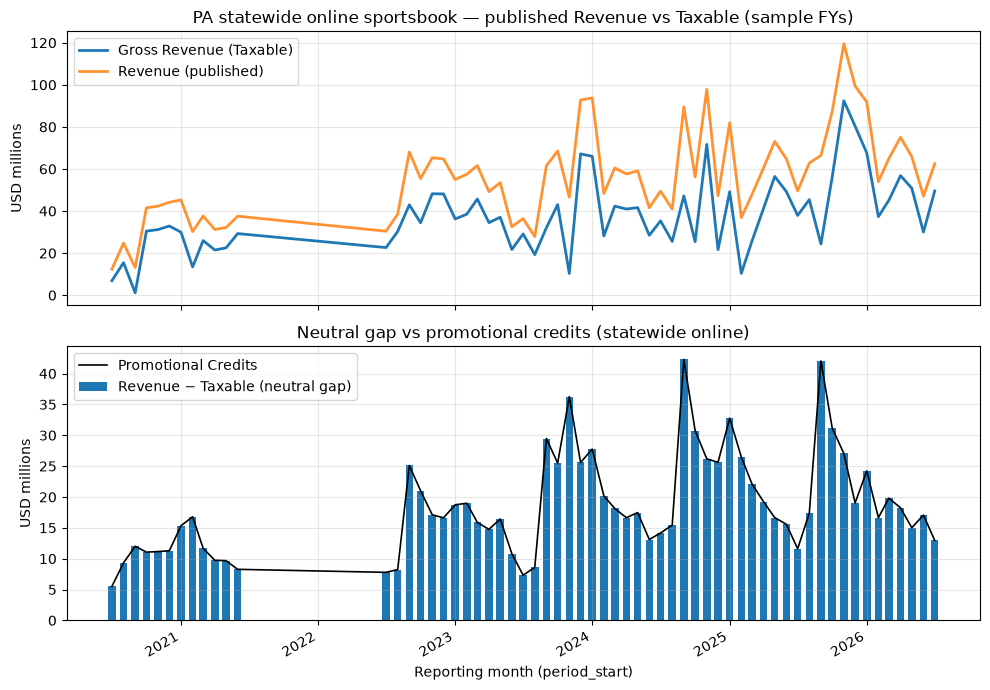

Statewide online diagnostic table (tail):


,source_fy,period_start,revenue,promotional_credits,gross_revenue_taxable,revenue_minus_taxable
60,FY 2025/2026,2025-08-01,6.280615e+07,17382545.86,45423605.33,17382545.86
61,FY 2025/2026,2025-09-01,6.639747e+07,42043915.55,24353553.06,42043915.55
62,FY 2025/2026,2025-10-01,8.732120e+07,31169901.31,56151294.79,31169901.30
63,FY 2025/2026,2025-11-01,1.194906e+08,27056624.90,92433985.52,27056624.90
64,FY 2025/2026,2025-12-01,9.940310e+07,19025504.05,80377594.55,19025504.05
65,FY 2025/2026,2026-01-01,9.184174e+07,24217864.11,67623871.74,24217864.11
66,FY 2025/2026,2026-02-01,5.396913e+07,16638392.32,37330735.56,16638392.32
67,FY 2025/2026,2026-03-01,6.497171e+07,19813170.89,45158536.06,19813170.89
68,FY 2025/2026,2026-04-01,7.505740e+07,18220037.12,56837358.41,18220037.12
69,FY 2025/2026,2026-05-01,6.581057e+07,15006963.70,50803611.22,15006963.70


In [9]:
statewide_online = online[online["operator_native"].map(_normalize_label) == "grand total"].copy()
statewide_online = statewide_online.sort_values("period_start")
for c in ["revenue", "promotional_credits", "gross_revenue_taxable"]:
    statewide_online[c] = statewide_online[c].map(lambda x: float(x) if x is not None else None)

plot_df = statewide_online.dropna(subset=["gross_revenue_taxable"]).copy()
plot_df["period"] = pd.to_datetime(plot_df["period_start"])

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(plot_df["period"], plot_df["gross_revenue_taxable"] / 1e6, label="Gross Revenue (Taxable)", linewidth=2)
axes[0].plot(plot_df["period"], plot_df["revenue"] / 1e6, label="Revenue (published)", linewidth=2, alpha=0.85)
axes[0].set_ylabel("USD millions")
axes[0].set_title("PA statewide online sportsbook — published Revenue vs Taxable (sample FYs)")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.3)

gap = plot_df["revenue"] - plot_df["gross_revenue_taxable"]
axes[1].bar(plot_df["period"], gap / 1e6, width=20, label="Revenue − Taxable (neutral gap)")
axes[1].plot(plot_df["period"], plot_df["promotional_credits"] / 1e6, color="black", linewidth=1.2, label="Promotional Credits")
axes[1].set_ylabel("USD millions")
axes[1].set_xlabel("Reporting month (period_start)")
axes[1].set_title("Neutral gap vs promotional credits (statewide online)")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

summary_tbl = plot_df[
    ["source_fy", "period_start", "revenue", "promotional_credits", "gross_revenue_taxable"]
].copy()
summary_tbl["revenue_minus_taxable"] = summary_tbl["revenue"] - summary_tbl["gross_revenue_taxable"]
print("Statewide online diagnostic table (tail):")
display(summary_tbl.tail(12))


## Downstream mapping conflict (`consolidate.revenue_basis` + notebook 40)

**What.** Inspect how populating `gross_revenue` interacts with consolidation labeling and notebook 40's cross-state comparison filter.

**Why.** Preserving a published PGCB field and approving cross-state comparability are **separate decisions**. A storage write is not automatically a cohort-eligibility decision.

**Assumptions.** Current production code paths remain unchanged in this notebook. We document conflict only; we do **not** implement an eligibility framework, schema change, or special case.

**Inspect.** Exact `revenue_basis` priority and notebook 40 inclusion rules; smallest implementation alternatives and tradeoffs.


In [10]:
import inspect
from variant_gaming.consolidate import revenue_basis, revenue_amount

print("=== consolidate.revenue_basis (production) ===")
print(inspect.getsource(revenue_basis))
print(inspect.getsource(revenue_amount))

print(
    "Implication: if PA online rows gain a non-null gross_revenue while taxable_revenue remains "
    "populated, revenue_basis(row) returns \"GGR\" because gross_revenue is checked first. "
    "The observation is then labeled GGR for consolidation exports regardless of whether PGCB "
    "'Revenue' is definitionally comparable to other states' GGR."
)

demo = pd.DataFrame(
    [
        {
            "case": "status_quo_PA_online",
            "gross_revenue": pd.NA,
            "adjusted_revenue": pd.NA,
            "taxable_revenue": 1_000_000.0,
            "net_proceeds": pd.NA,
        },
        {
            "case": "naive_Revenue_into_gross_revenue",
            "gross_revenue": 1_200_000.0,
            "adjusted_revenue": pd.NA,
            "taxable_revenue": 1_000_000.0,
            "net_proceeds": pd.NA,
        },
    ]
)
demo["revenue_basis"] = demo.apply(revenue_basis, axis=1)
demo["revenue_amount"] = demo.apply(revenue_amount, axis=1)
print("Illustrative labeling effect (synthetic numbers):")
display(demo)

print("\n=== notebook 40 comparison filter (handle-plus-GGR cohort) ===")
print(
    "From notebooks/40_sqlite_ggr_analysis.ipynb — comparable multi-state online sportsbooks:\n"
    "  Inclusion rules (all required):\n"
    "  - vertical == online sports betting\n"
    "  - frequency == monthly\n"
    "  - revenue_basis == 'GGR'\n"
    "  - positive, non-null handle\n"
    "  - non-null revenue\n"
    "Therefore a naive Revenue → gross_revenue write would automatically make PA eligible for that "
    "GGR cohort via revenue_basis, without any separate comparability review."
)

print("\n=== Decision separation ===")
print("1. Field preservation: may PGCB Online 'Revenue' be retained as a published native field?")
print("2. Cross-state comparability: may that field enter GGR cohorts / be labeled revenue_basis=GGR?")
print("These are separate. Arithmetic identity alone does not answer (2).")

print("\n=== Smallest implementation alternatives (document only — do not implement) ===")
alternatives = pd.DataFrame(
    [
        {
            "alt": "A. Status quo",
            "change": "Keep taxable only; leave gross_revenue null",
            "pros": "No false GGR labeling; notebook 40 cohort unchanged",
            "cons": "Drops a published native Online line",
        },
        {
            "alt": "B. Naive Revenue → gross_revenue",
            "change": "Parser writes Revenue into gross_revenue; taxable unchanged",
            "pros": "Minimal parser diff; preserves published field in existing column",
            "cons": "Auto-labels PA as GGR via revenue_basis; notebook 40 would include PA without comparability decision — NOT safe standalone",
        },
        {
            "alt": "C. Preserve field, defer eligibility",
            "change": "Retain Revenue out-of-band / non-cohort until labeling policy is decided",
            "pros": "Avoids silent GGR promotion; keeps evidence",
            "cons": "Requires an explicit later decision; not implemented here (no new schema/framework in this notebook)",
        },
        {
            "alt": "D. Wait for definitional evidence",
            "change": "No storage change until PGCB/statute mapping of Revenue vs taxable vs statutory gross is resolved",
            "pros": "Highest definitional safety",
            "cons": "Continues to omit a published line from structured storage",
        },
    ]
)
display(alternatives)
print(
    "Provisional stance for this notebook: Revenue → gross_revenue remains a HYPOTHESIS only. "
    "It is not currently a safe standalone production change because of the GGR auto-label path."
)


=== consolidate.revenue_basis (production) ===
def revenue_basis(row: pd.Series) -> str | None:
    """Pick a single labeled revenue basis; never mix definitions silently."""
    if pd.notna(row.get("gross_revenue")):
        return "GGR"
    if pd.notna(row.get("adjusted_revenue")):
        return "AGR"
    if pd.notna(row.get("taxable_revenue")):
        return "taxable_revenue"
    if pd.notna(row.get("net_proceeds")):
        return "net_proceeds"
    return None

def revenue_amount(row: pd.Series) -> float | None:
    basis = revenue_basis(row)
    if basis == "GGR":
        return float(row["gross_revenue"])
    if basis == "AGR":
        return float(row["adjusted_revenue"])
    if basis == "taxable_revenue":
        return float(row["taxable_revenue"])
    if basis == "net_proceeds":
        return float(row["net_proceeds"])
    return None

Implication: if PA online rows gain a non-null gross_revenue while taxable_revenue remains populated, revenue_basis(row) returns "GGR" bec

,case,gross_revenue,adjusted_revenue,taxable_revenue,net_proceeds,revenue_basis,revenue_amount
0,status_quo_PA_online,<NA>,<NA>,1000000.0,<NA>,taxable_revenue,1000000.0
1,naive_Revenue_into_gross_revenue,1200000.0,<NA>,1000000.0,<NA>,GGR,1200000.0



=== notebook 40 comparison filter (handle-plus-GGR cohort) ===
From notebooks/40_sqlite_ggr_analysis.ipynb — comparable multi-state online sportsbooks:
  Inclusion rules (all required):
  - vertical == online sports betting
  - frequency == monthly
  - revenue_basis == 'GGR'
  - positive, non-null handle
  - non-null revenue
Therefore a naive Revenue → gross_revenue write would automatically make PA eligible for that GGR cohort via revenue_basis, without any separate comparability review.

=== Decision separation ===
1. Field preservation: may PGCB Online 'Revenue' be retained as a published native field?
2. Cross-state comparability: may that field enter GGR cohorts / be labeled revenue_basis=GGR?
These are separate. Arithmetic identity alone does not answer (2).

=== Smallest implementation alternatives (document only — do not implement) ===


,alt,change,pros,cons
0,A. Status quo,Keep taxable only; leave gross_revenue null,No false GGR labeling; notebook 40 cohort unch...,Drops a published native Online line
1,B. Naive Revenue → gross_revenue,Parser writes Revenue into gross_revenue; taxa...,Minimal parser diff; preserves published field...,Auto-labels PA as GGR via revenue_basis; noteb...
2,"C. Preserve field, defer eligibility",Retain Revenue out-of-band / non-cohort until ...,Avoids silent GGR promotion; keeps evidence,Requires an explicit later decision; not imple...
3,D. Wait for definitional evidence,No storage change until PGCB/statute mapping o...,Highest definitional safety,Continues to omit a published line from struct...


Provisional stance for this notebook: Revenue → gross_revenue remains a HYPOTHESIS only. It is not currently a safe standalone production change because of the GGR auto-label path.


## Final validation and recommendation

**What.** Record findings, reconciliation results, semantic layers, downstream conflict, coverage limits, and a go/no-go for **research review** (not production merge).

**Why.** This notebook is methodology research — it must not alter shared contracts, schema, collectors, or eligibility frameworks.

**Assumptions.** Recommendation concerns readiness for research review and the specific decisions still required before any production implementation.


In [11]:
findings = {
    "question": "Does PA publish a gross sportsbook revenue measure separable from taxable?",
    "short_answer": (
        "Online (and Total) sections publish a native 'Revenue' line alongside "
        "'Gross Revenue (Taxable)' and 'Promotional Credits'. Retail generally publishes taxable without Revenue/Promo. "
        "Arithmetic supports Revenue − Promo = Taxable on Online rows in this sample. "
        "That does NOT by itself establish that workbook Revenue equals statutory gross or cross-state GGR."
    ),
    "sample_grain": "six fiscal-year workbooks with monthly columns (not six independent monthly files)",
    "online_identity_n": int(len(online_identity)),
    "online_identity_n_operator_detail": int(len(online_ops_id)),
    "online_identity_n_grand_total_control": int(len(online_ctrl_id)),
    "online_identity_failures": int((~online_identity["pass_tol_0_01"]).sum()),
    "online_identity_max_abs_diff": float(online_identity["abs_diff"].max()) if len(online_identity) else None,
    "total_identity_failures": int((~total_identity["pass_tol_0_01"]).sum()),
    "total_identity_max_abs_diff": float(total_identity["abs_diff"].max()) if len(total_identity) else None,
    "total_failures_also_fail_online": int(
        (
            total_identity.loc[~total_identity["pass_tol_0_01"]]
            .merge(
                online_identity,
                on=["source_fy", "operator_native", "period_start"],
                how="left",
                suffixes=("_total", "_online"),
            )["pass_tol_0_01_online"]
            == False
        ).sum()
    )
    if len(total_identity) and (~total_identity["pass_tol_0_01"]).any()
    else 0,
    "tax_monthly_34pct_failures_at_0_01": int((~tax_df["pass_state_tol_0_01"]).sum()) if len(tax_df) else None,
    "tax_monthly_34pct_max_abs_diff": float(tax_df["abs_state_diff"].max()) if len(tax_df) else None,
    "parser_taxable_max_abs_diff_vs_research": float(both["taxable_diff"].abs().max()) if len(both) else None,
    "sample_periods_min": str(observations["period_start"].min()),
    "sample_periods_max": str(observations["period_start"].max()),
    "latest_completed_month_in_latest_fy": str(latest_period),
    "production_db_compared": False,
    "downstream_conflict": (
        "Populating gross_revenue causes consolidate.revenue_basis to return GGR; "
        "notebook 40 handle+GGR cohort would then include PA without a separate comparability decision."
    ),
}

print("FINDINGS")
for k, v in findings.items():
    print(f"  {k}: {v}")

print("\nVALIDATED (workbook / parser evidence)")
print("  - Six FY Excel sports summaries expose monthly Online vs Retail vs Total sections.")
print("  - Online publishes Revenue, Promotional Credits, and Gross Revenue (Taxable).")
print("  - Existing parser online taxable/handle/tax match research extracts on these six files.")
print("  - Online arithmetic identity Revenue − Promo = Taxable holds within $0.01 for all Online cells tested.")
print("  - Total-section failures (if any) are displayed with provenance and do not automatically refute Online rows.")

print("\nOFFICIAL DEFINITION (cited docs)")
print("  - Statutory/regulatory 'gross sports wagering revenue' is the 34% tax base definition.")
print("  - Workbook footnote addresses Handle* timing vs Gross Revenue; it does not define bare 'Revenue'.")

print("\nUNCERTAIN (interpretation)")
print("  - Whether workbook 'Revenue' equals statutory gross sports wagering revenue.")
print("  - Whether 'Revenue' is cross-state GGR-comparable.")
print("  - Exact components of Promotional Credits (neutral label retained).")
print("  - Publication/revision timestamps remain unknown.")
print("  - Full-history layout stability beyond these six FY files.")

print("\nEDGE CASES")
print("  - FY workbook sheet titles can mismatch filename year (month headers still govern).")
print("  - Total-section identity outliers exist in source (see full failure table above).")
print("  - Retail omits Revenue/Promo lines — do not invent them.")
print("  - Negative taxable/revenue months occur and must be preserved.")
print("  - Operator label spelling/case drifts across years.")
print("  - Monthly state tax is not always exact round(month_taxable*0.34,¢); do not reverse tax.")

print("\nCOVERAGE / SAMPLING LIMITS")
print("  - Sample = six fiscal-year workbooks, not six independent monthly report files.")
print("  - Online reconciliation n counts workbook cells with both Revenue and Taxable; includes GRAND TOTAL controls.")
print("  - Do not treat repeated totals or overlapping workbook observations as independent validation evidence.")
print("  - Latest FY sample may contain only the first completed month(s) at retrieval time.")
print("  - Tracked fixture remains a test input until provenance is established.")

print("\nREPORTED vs DERIVED")
print("  - Revenue, Promotional Credits, Gross Revenue (Taxable), taxes: REPORTED.")
print("  - Revenue − Taxable gap: DERIVED diagnostic; equals Promo when identity holds.")
print("  - Tax inversion to impute gross: FORBIDDEN / not used.")

print("\nDOWNSTREAM CONFLICT")
print("  - Field preservation ≠ cohort eligibility.")
print("  - Revenue → gross_revenue is NOT currently a safe standalone production change.")
print("  - Mapping stays provisional until meaning + downstream eligibility are resolved.")
print("  - No eligibility framework / schema / special case implemented in this notebook.")

print("\nMINIMAL ALTERNATIVES (document only)")
print("  A. Status quo (taxable only)")
print("  B. Naive Revenue → gross_revenue (unsafe standalone due to GGR auto-label)")
print("  C. Preserve field while deferring eligibility/labeling decision")
print("  D. Wait for stronger definitional evidence before any storage change")

recommendation = "ready for research review"
print("\nRECOMMENDATION:", recommendation)
print(
    "Before production implementation, research review must specifically decide:\n"
    "  (1) whether to retain PGCB Online 'Revenue' as a preserved published field at all;\n"
    "  (2) whether that field may populate gross_revenue given consolidate.revenue_basis → GGR;\n"
    "  (3) whether PA may enter notebook 40's handle+GGR cohort / other cross-state GGR uses;\n"
    "  (4) what evidence would equate workbook 'Revenue' with statutory gross (arithmetic alone is insufficient).\n"
    "Until those decisions are made, do not implement production parser/schema/eligibility changes."
)

assert not (ROOT / "data" / "gaming.sqlite").exists()
print("\nConfirmed: no production SQLite present; no DB comparison performed.")


FINDINGS
  question: Does PA publish a gross sportsbook revenue measure separable from taxable?
  short_answer: Online (and Total) sections publish a native 'Revenue' line alongside 'Gross Revenue (Taxable)' and 'Promotional Credits'. Retail generally publishes taxable without Revenue/Promo. Arithmetic supports Revenue − Promo = Taxable on Online rows in this sample. That does NOT by itself establish that workbook Revenue equals statutory gross or cross-state GGR.
  sample_grain: six fiscal-year workbooks with monthly columns (not six independent monthly files)
  online_identity_n: 790
  online_identity_n_operator_detail: 729
  online_identity_n_grand_total_control: 61
  online_identity_failures: 0
  online_identity_max_abs_diff: 0.01
  total_identity_failures: 6
  total_identity_max_abs_diff: 1212.9
  total_failures_also_fail_online: 0
  tax_monthly_34pct_failures_at_0_01: 21
  tax_monthly_34pct_max_abs_diff: 0.640000002
  parser_taxable_max_abs_diff_vs_research: 0.0
  sample_periods_

### Key findings (executive)

1. **Separate published line exists (Online).** PGCB online sports worksheets publish `Revenue` beside `Gross Revenue (Taxable)` and `Promotional Credits`.
2. **Arithmetic (workbook-established).** Online sample cells satisfy `Revenue − Promotional Credits = Gross Revenue (Taxable)` within $0.01. This is **not** by itself an official definition that workbook `Revenue` equals statutory gross.
3. **Sample grain.** Evidence comes from **six fiscal-year workbooks** with monthly columns. The Online reconciliation denominator is workbook-scoped cells (operator detail + GRAND TOTAL controls), not N independent monthly files.
4. **Total-section exceptions.** All Total-channel identity failures are listed with URL/workbook/sheet/period/entity/values/residual. They do **not** generalize Online validation to retail or combined totals.
5. **Downstream conflict.** Writing `Revenue` into `gross_revenue` would auto-label PA as `revenue_basis == "GGR"` via `consolidate.revenue_basis`, and notebook 40's handle+GGR filter would treat it as comparable GGR. **Not a safe standalone change.**
6. **Recommendation.** **Ready for research review.** Production implementation requires explicit decisions on field preservation vs GGR labeling/eligibility; mapping remains provisional.
